# VQE-based Prime Factorization
*Sobhani, M., Chai, Y., Hartung, T., & Jansen, K. (2025). Variational quantum eigensolver approach to prime factorization on IBM’s noisy intermediate scale quantum computer. Physical Review A, 111(4). https://doi.org/10.1103/PhysRevA.111.042413*

In [1]:
#!pip install qiskit qiskit-aer scipy numpy pylatexenc qiskit-algorithms

In [2]:
import numpy as np
from math import ceil, log2
from itertools import product
from scipy.optimize import minimize
from qiskit_algorithms.optimizers import COBYLA, NFT
from typing import Optional
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.primitives import StatevectorSampler

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram

In [3]:
np.random.seed(42)

In [41]:
QiskitRuntimeService.save_account(
token="ODLpd_EUIGoIt2vHGGPrwWyOp8iS7t6xv3BSvFQC-gAm", # Use the 44-character API_KEY you created and saved from the IBM Quantum Platform Home dashboard
instance="crn:v1:bluemix:public:quantum-computing:us-east:a/8c17b2a36c674160ba9fe40a58da9634:7c59c43b-abf2-45f5-9e06-c37c2a1adfb0::", # Optional: Use the CRN you created and saved from the IBM Quantum Platform Home dashboard
channel="ibm_cloud", # Optional: Use "ibm_quantum" for public access or "ibm_quantum_private" for private access
overwrite=True # Optional: Overwrite existing saved accounts
)
service = QiskitRuntimeService(channel="ibm_cloud")
print(service.backends())  # list available backends

hw_backend = service.least_busy(operational=True, simulator=False, min_num_qubits = 127)
sim_backend = AerSimulator() # Use simulator by default

print(hw_backend.name)

[<IBMBackend('ibm_fez')>, <IBMBackend('ibm_kingston')>, <IBMBackend('ibm_marrakesh')>]
ibm_fez


## Contructing Hamiltonian

In [5]:
def get_qubit_counts(n: int) -> tuple[int, int, int]:
    """
    Compute Np, Nq, and total qubit count N for a given n.
    As per the paper: p <= sqrt(n), q < n/2, both odd => drop LSB.
    """
    B = ceil(log2(n + 1))
    Np = ceil(log2(n**0.5 + 1))   # bits for p (incl. p0=1)
    Nq = B - 1                     # bits for q (incl. q0=1)
    N = (Np - 1) + (Nq - 1)       # free qubits (strip fixed LSBs)
    return Np, Nq, N


def bitstring_to_pq(bits: str, Np: int, Nq: int) -> tuple[int, int]:
    """
    Convert a measurement bitstring to factor integers p, q.
    Qiskit bit order: rightmost bit = qubit 0.
    Layout: |p_{Np-1} ... p_1  q_{Nq-1} ... q_1⟩
    LSBs p0=q0=1 are appended.
    """
    bits = bits[::-1]              # reverse to LSB-first order
    q_bits = [int(b) for b in bits[:Nq - 1]]    # q1 .. q_{Nq-1}
    p_bits = [int(b) for b in bits[Nq - 1:]]    # p1 .. p_{Np-1}

    p = 1 + sum(p_bits[j] * (2 ** (j + 1)) for j in range(len(p_bits)))
    q = 1 + sum(q_bits[k] * (2 ** (k + 1)) for k in range(len(q_bits)))
    return p, q


def cost_fn(p: int, q: int, n: int, cost_type: str = "hamiltonian") -> float:
    """
    Evaluate cost function for a given (p, q) candidate.
    Three types as described in Section VI.C of the paper:
      - 'hamiltonian': (n - pq)^2
      - 'logarithm':   log(|n - pq| + 1)
      - 'inverse':     -1 / (|n - pq| + 0.001)
    """
    diff = abs(n - p * q)
    if cost_type == "hamiltonian":
        return float(diff ** 2)
    elif cost_type == "logarithm":
        return float(np.log(diff + 1))
    elif cost_type == "inverse":
        return -1.0 / (diff + 0.001)
    else:
        raise ValueError(f"Unknown cost_type: {cost_type}")



## Quantum circuit

In [6]:
def build_linear_cnot_ansatz(N: int, L: int, params: np.ndarray) -> "QuantumCircuit":
    """
    Build the hardware-efficient linear-CNOT ansatz described in Section III / Fig. 2.
    N qubits, L layers.
    Each layer: RY(theta) on each qubit, then CNOT ladder (qubit i -> i+1).
    Total parameters: N * L RY gates.
    """
    qc = QuantumCircuit(N)

    # Hadamard initialisation (puts qubits in |+> superposition)
    qc.h(range(N))

    param_idx = 0
    for layer in range(L):
        # RY rotations
        for q in range(N):
            qc.ry(params[param_idx], q)
            param_idx += 1
        # Linear CNOT entangling layer (skip for last layer per Fig. 2)
        if layer < L - 1:
            for q in range(N - 1):
                qc.cx(q, q + 1)

    qc.measure_all()
    return qc


def num_params(N: int, L: int) -> int:
    return N * L

## CVaR cost function evaluation

In [7]:
def cvar(eigenvalues: list[float], alpha: float) -> float:
    """
    Conditional Value at Risk (CVaR) as in Eq. (8) of the paper.
    Takes the expectation of the lowest alpha-fraction of measured eigenvalues.
    """
    sorted_evals = sorted(eigenvalues)
    k = max(1, int(np.ceil(alpha * len(sorted_evals))))
    return float(np.mean(sorted_evals[:k]))


def evaluate_cost(
    params: np.ndarray,
    n: int,
    Np: int,
    Nq: int,
    N: int,
    L: int,
    shots: int,
    alpha: float,
    cost_type: str,
    simulator: "AerSimulator",
    best_found: dict,
) -> float:
    """
    Build circuit, run on simulator, compute CVaR cost.
    Also tracks the best (p, q) solution found so far.
    """
    qc = build_linear_cnot_ansatz(N, L, params)
    job = simulator.run(qc, shots=shots)
    counts = job.result().get_counts()

    eigenvalues = []
    for bitstring, count in counts.items():
        p, q = bitstring_to_pq(bitstring, Np, Nq)
        ev = cost_fn(p, q, n, cost_type)
        eigenvalues.extend([ev] * count)

        # Track best solution
        if p * q == n and p > 1 and q > 1:
            best_found["p"] = p
            best_found["q"] = q
            best_found["found"] = True

    return cvar(eigenvalues, alpha), best_found

## Optimisation

In [8]:
def nft_minimize(obj, params0, max_iter=80):
    """
    Proxy for the NFT (Sequential Minimal Optimization) optimizer
    [Nakanishi et al., PRR 2020]. Coordinate-wise sinusoidal updates.
    """
    params = params0.copy()
    for it in range(min(max_iter, 120)):
        i = it % len(params)
        bv = obj(params)
        for shift in [np.pi / 2, np.pi, 3 * np.pi / 2]:
            trial = params.copy(); trial[i] += shift
            v = obj(trial)
            if v < bv: bv = v; params = trial
    return params

In [9]:
def run_vqe(
    n: int,
    L: int = 3,
    shots: int = 1000,
    alpha: float = 0.1,
    cost_type: str = "hamiltonian",
    max_iter: Optional[int] = None,
    optimizer: str = "COBYLA",
    initial_params: Optional[np.ndarray] = None,
    verbose: bool = True,
) -> dict:
    """
    Run one VQE trial to factor n.

    Parameters
    ----------
    n          : integer to factor
    L          : number of ansatz layers
    shots      : measurement shots per evaluation
    alpha      : CVaR percentile (0 < alpha <= 1)
    cost_type  : 'hamiltonian', 'logarithm', or 'inverse'
    max_iter   : COBYLA max iterations (default: 50*N*L per paper)
    initial_params : optional starting angles; random if None
    verbose    : print progress

    Returns
    -------
    dict with keys: found, p, q, n, iterations, success_fidelity, history
    """

    assert n % 2 == 1 and n > 1, "n must be an odd integer > 1"

    Np, Nq, N = get_qubit_counts(n)
    n_params = num_params(N, L)
    if max_iter is None:
        max_iter = 50 * N * L

    simulator = AerSimulator()
    best_found = {"found": False, "p": None, "q": None}
    iteration_count = [0]
    history = [] # Initialize history list

    if initial_params is None:
        params0 = np.random.uniform(-np.pi, np.pi, n_params)
    else:
        params0 = initial_params.copy()

    if verbose:
        print(f"\n{'─'*55}")
        print(f"  Factoring n = {n}")
        print(f"  Qubits N={N}  |  Layers L={L}  |  alpha={alpha}")
        print(f"  Cost: {cost_type}  |  Shots: {shots}  |  MaxIter: {max_iter}")
        print(f"{'─'*55}")

    def objective(params):
        iteration_count[0] += 1
        cv, _ = evaluate_cost(params, n, Np, Nq, N, L, shots, alpha, cost_type, simulator, best_found)
        history.append(cv) # Store the CVaR cost
        if verbose and iteration_count[0] % 10 == 0:
            status = f"  -> Found p={best_found['p']}, q={best_found['q']}" if best_found["found"] else ""
            print(f"  Iter {iteration_count[0]:4d}  |  CVaR = {cv:.4f}{status}")
        return cv

    # result = minimize(
    #     objective,
    #     params0,
    #     method="COBYLA",
    #     options={"maxiter": max_iter, "rhobeg": 0.5},
    # )
    if optimizer == "COBYLA":
        optimizer = COBYLA(maxiter=max_iter)
    elif optimizer == "NFT":
        # NFT params: maxiter (outer loops), reset_interval (default 32)
        # Larger reset_interval = more thorough but slower per restart
        optimizer = NFT(maxiter=max_iter, maxfev=max_iter * N * L, reset_interval=32)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer}. Use 'COBYLA' or 'NFT'.")

    result = optimizer.minimize(fun=objective, x0=params0)


    # Final measurement pass to extract solution if not yet found
    if not best_found["found"]:
        qc = build_linear_cnot_ansatz(N, L, result.x)
        job = simulator.run(qc, shots=shots * 5)
        counts = job.result().get_counts()
        for bitstring in sorted(counts, key=counts.get, reverse=True):
            p, q = bitstring_to_pq(bitstring, Np, Nq)
            if p * q == n and p > 1 and q > 1:
                best_found.update({"found": True, "p": p, "q": q})
                break

    if verbose:
        if best_found["found"]:
            print(f"\n  -> SUCCESS: {n} = {best_found['p']} × {best_found['q']}")
        else:
            print(f"\n  X Not found after {iteration_count[0]} iterations.")
        print(f"{'─'*55}\n")

    return {
        "found": best_found["found"],
        "p": best_found["p"],
        "q": best_found["q"],
        "n": n,
        "iterations": iteration_count[0],
        "history": history # Return the history list
    }

In [10]:
def benchmark(
    n: int,
    num_runs: int = 10,
    L: int = 3,
    shots: int = 1000,
    alpha: float = 0.1,
    cost_type: str = "hamiltonian",
    verbose: bool = False,
) -> dict:
    """
    Run VQE num_runs times with random initialisations and report success rate.
    Mirrors the paper's evaluation methodology (Section IV).
    """
    successes = 0
    iters_list = []

    print(f"\nBenchmarking n={n} over {num_runs} runs (L={L}, alpha={alpha}, cost={cost_type})")
    for i in range(num_runs):
        result = run_vqe(n, L=L, shots=shots, alpha=alpha, cost_type=cost_type, verbose=verbose)
        if result["found"]:
            successes += 1
            iters_list.append(result["iterations"])
        print(f"  Run {i+1:2d}/{num_runs}  |  {'->' if result['found'] else '✗'}  "
              f"|  iters={result['iterations']}")

    success_rate = successes / num_runs
    avg_iters = np.mean(iters_list) if iters_list else float("nan")
    print(f"\n  Success rate: {success_rate:.0%}  |  Avg iters (successes): {avg_iters:.1f}\n")
    return {"n": n, "success_rate": success_rate, "avg_iters": avg_iters, "runs": num_runs}


In [11]:
def factorize(n: int, **kwargs) -> Optional[tuple[int, int]]:
    """
    Attempt to factor n using VQE.  Returns (p, q) or None.
    Extra keyword args are forwarded to run_vqe().
    """
    result = run_vqe(n, **kwargs)
    if result["found"]:
        return result["p"], result["q"]
    return None

In [12]:
print("=" * 55)
print("  VQE Prime Factorization (Sobhani et al., PRA 2025)")
print("=" * 55)

# ── Quick single-run demos ──────────────────────────────────────────────
# These are from Table I / Table II of the paper.

examples = [
    # (n,  L,   alpha,  shots)
    (15,   3,   0.5,    1000),   # 3×5,  3 qubits
    (21,   3,   0.5,    1000),   # 3×7,  5 qubits
    (57,   3,   0.5,    1000),   # 3×19, 6 qubits
    (123,  3,   0.25,   1000),   # 3×41, 8 qubits
    (253,  3,   0.25,   1000),   # 11×23, 9 qubits
    (511,  4,   0.25,   1000)    # 7X73, 11 qubits
]

for (n, L, alpha, shots) in examples:
    run_vqe(n, L=L, shots=shots, alpha=alpha, cost_type="hamiltonian", verbose=True)

# ── Benchmark: success rate over multiple runs ──────────────────────────
# Uncomment to replicate Fig. 3 style analysis for n=15.
# benchmark(15, num_runs=20, L=3, alpha=0.1, shots=1000)

# ── Cost function comparison (Section VI.C) ─────────────────────────────
# The paper compares hamiltonian / logarithm / inverse cost functions.
# Uncomment to test:
# for ctype in ["hamiltonian", "logarithm", "inverse"]:
#      run_vqe(57, L=3, shots=2000, alpha=0.01, cost_type=ctype, verbose=True)

# print("Done.")

  VQE Prime Factorization (Sobhani et al., PRA 2025)

───────────────────────────────────────────────────────
  Factoring n = 15
  Qubits N=4  |  Layers L=3  |  alpha=0.5
  Cost: hamiltonian  |  Shots: 1000  |  MaxIter: 600
───────────────────────────────────────────────────────
  Iter   10  |  CVaR = 29.0880  -> Found p=5, q=3
  Iter   20  |  CVaR = 1.6560  -> Found p=3, q=5
  Iter   30  |  CVaR = 0.0000  -> Found p=5, q=3
  Iter   40  |  CVaR = 0.0000  -> Found p=5, q=3
  Iter   50  |  CVaR = 0.0000  -> Found p=3, q=5
  Iter   60  |  CVaR = 0.0000  -> Found p=3, q=5
  Iter   70  |  CVaR = 0.0000  -> Found p=5, q=3
  Iter   80  |  CVaR = 0.0000  -> Found p=5, q=3

  -> SUCCESS: 15 = 5 × 3
───────────────────────────────────────────────────────


───────────────────────────────────────────────────────
  Factoring n = 21
  Qubits N=5  |  Layers L=3  |  alpha=0.5
  Cost: hamiltonian  |  Shots: 1000  |  MaxIter: 750
───────────────────────────────────────────────────────
  Iter   10  |  C

## Plots

In [13]:
SIM     = AerSimulator()
COLORS  = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
plt.rcParams.update({
    "font.family"      : "DejaVu Sans",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.alpha"       : 0.25,
    "axes.labelsize"   : 11,
    "axes.titlesize"   : 12,
    "legend.fontsize"  : 9,
})

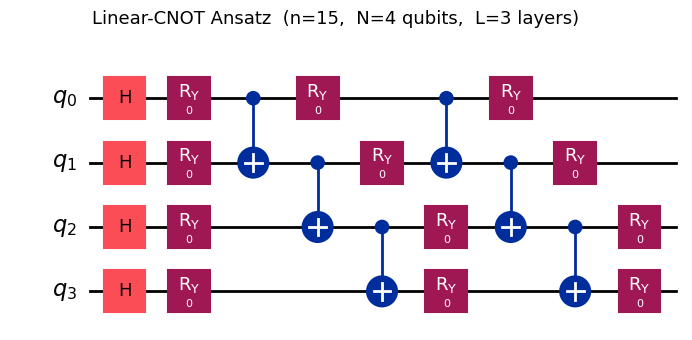

circuit_diagram.png


In [14]:
# Quantum circuit diagram (linear-CNOT ansatz)
n=15
L=3
Np, Nq, N = get_qubit_counts(n)
params = np.zeros(N * L)

def build_ansatz(N, L, params):
    """
    Hardware-efficient linear-CNOT ansatz (Fig. 2 of paper).
    N qubits, L layers. Each layer: H-init → RY rotations → CNOT ladder.
    Total parameters = N * L.
    """
    qc = QuantumCircuit(N)
    qc.h(range(N))
    idx = 0
    for layer in range(L):
        for q in range(N):
            qc.ry(params[idx], q); idx += 1
        if layer < L - 1:
            for q in range(N - 1):
                qc.cx(q, q + 1)
    qc.measure_all()
    return qc

qc     = build_ansatz(N, L, params).remove_final_measurements(inplace=False)
fig    = qc.draw(output="mpl", fold=-1, plot_barriers=False)
fig.suptitle(
    f"Linear-CNOT Ansatz  (n={n},  N={N} qubits,  L={L} layers)",
    fontsize=13, #y=1.02,
)
fig.savefig("circuit_diagram.png", dpi=150, bbox_inches="tight")
plt.show()
display(fig)
print("circuit_diagram.png")


───────────────────────────────────────────────────────
  Factoring n = 15
  Qubits N=4  |  Layers L=3  |  alpha=0.01
  Cost: hamiltonian  |  Shots: 1000  |  MaxIter: 60
───────────────────────────────────────────────────────
  Iter   10  |  CVaR = 0.0000  -> Found p=3, q=5
  Iter   20  |  CVaR = 0.0000  -> Found p=5, q=3
  Iter   30  |  CVaR = 0.0000  -> Found p=3, q=5
  Iter   40  |  CVaR = 0.0000  -> Found p=3, q=5
  Iter   50  |  CVaR = 0.0000  -> Found p=3, q=5
  Iter   60  |  CVaR = 0.0000  -> Found p=5, q=3

  -> SUCCESS: 15 = 5 × 3
───────────────────────────────────────────────────────


───────────────────────────────────────────────────────
  Factoring n = 15
  Qubits N=4  |  Layers L=3  |  alpha=0.01
  Cost: hamiltonian  |  Shots: 1000  |  MaxIter: 60
───────────────────────────────────────────────────────
  Iter   10  |  CVaR = 3.6000  -> Found p=3, q=5
  Iter   20  |  CVaR = 0.0000  -> Found p=3, q=5
  Iter   30  |  CVaR = 0.0000  -> Found p=3, q=5
  Iter   40  |  CVaR =

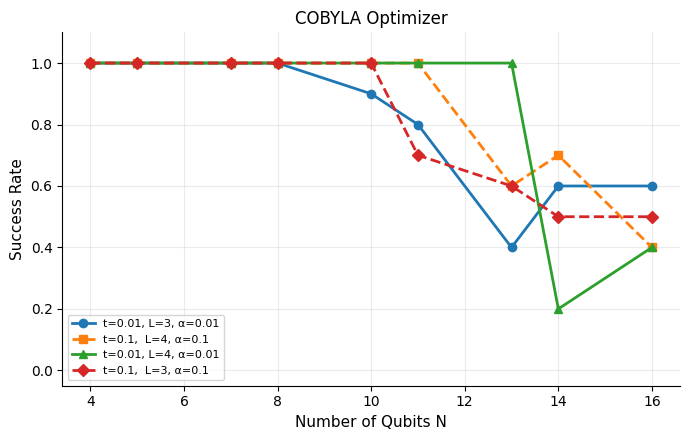

In [15]:
# Success rate vs qubit count (4 configs)
runs=10
shots=1000
instances = [(15, 3), (21, 5), (57, 6), (123, 8), (253, 9),(511, 11),(1011, 13),(2047, 14),(4087, 16),]
configs = [
    {"L": 3, "alpha": 0.01, "label": "t=0.01, L=3, α=0.01", "ls": "-",  "mk": "o"},
    {"L": 4, "alpha": 0.10, "label": "t=0.1,  L=4, α=0.1",  "ls": "--", "mk": "s"},
    {"L": 4, "alpha": 0.01, "label": "t=0.01, L=4, α=0.01", "ls": "-",  "mk": "^"},
    {"L": 3, "alpha": 0.10, "label": "t=0.1,  L=3, α=0.1",  "ls": "--", "mk": "D"},
]
fig, ax = plt.subplots(figsize=(7, 4.5))
for cfg, color in zip(configs, COLORS):
    rates, nqs = [], []
    for n, _ in instances:
        Np, Nq, N = get_qubit_counts(n); succ = 0
        for _ in range(runs):
            result = run_vqe(n, L=cfg["L"], shots=shots,
                                alpha=cfg["alpha"], max_iter=60)
            found = result["found"]
            if found: succ += 1
        rates.append(succ / runs); nqs.append(N)
        print(f"      [{cfg['label']}] N={N} → {succ/runs:.0%}")
    ax.plot(nqs, rates, color=color, ls=cfg["ls"],
            marker=cfg["mk"], ms=6, lw=2, label=cfg["label"])
ax.set_xlabel("Number of Qubits N")
ax.set_ylabel("Success Rate")
ax.set_title("COBYLA Optimizer")
ax.set_ylim(-0.05, 1.1)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig("success_rate_COBYLA.png", dpi=150, bbox_inches="tight")
#display(fig)
print("success_rate_COBYLA.png")


───────────────────────────────────────────────────────
  Factoring n = 15
  Qubits N=4  |  Layers L=3  |  alpha=0.01
  Cost: hamiltonian  |  Shots: 1000  |  MaxIter: 60
───────────────────────────────────────────────────────
  Iter   10  |  CVaR = 0.0000  -> Found p=5, q=3
  Iter   20  |  CVaR = 0.0000  -> Found p=3, q=5
  Iter   30  |  CVaR = 0.0000  -> Found p=3, q=5
  Iter   40  |  CVaR = 0.0000  -> Found p=5, q=3
  Iter   50  |  CVaR = 0.0000  -> Found p=3, q=5
  Iter   60  |  CVaR = 0.0000  -> Found p=3, q=5
  Iter   70  |  CVaR = 0.0000  -> Found p=3, q=5
  Iter   80  |  CVaR = 0.0000  -> Found p=5, q=3
  Iter   90  |  CVaR = 0.0000  -> Found p=3, q=5
  Iter  100  |  CVaR = 0.0000  -> Found p=3, q=5
  Iter  110  |  CVaR = 0.0000  -> Found p=3, q=5
  Iter  120  |  CVaR = 0.0000  -> Found p=3, q=5

  -> SUCCESS: 15 = 3 × 5
───────────────────────────────────────────────────────


───────────────────────────────────────────────────────
  Factoring n = 15
  Qubits N=4  |  Layers L=

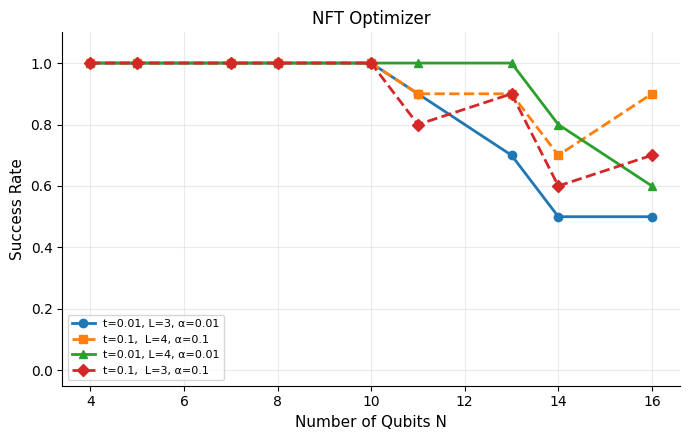

In [17]:
# Success rate vs qubit count (4 configs)
fig, ax = plt.subplots(figsize=(7, 4.5))
for cfg, color in zip(configs, COLORS):
    rates, nqs = [], []
    for n, _ in instances:
        Np, Nq, N = get_qubit_counts(n); succ = 0
        for _ in range(runs):
            result = run_vqe(n, L=cfg["L"], shots=shots,
                                alpha=cfg["alpha"], max_iter=60, optimizer = "NFT")
            found = result["found"]
            if found: succ += 1
        rates.append(succ / runs); nqs.append(N)
        print(f"      [{cfg['label']}] N={N} → {succ/runs:.0%}")
    ax.plot(nqs, rates, color=color, ls=cfg["ls"],
            marker=cfg["mk"], ms=6, lw=2, label=cfg["label"])
ax.set_xlabel("Number of Qubits N")
ax.set_ylabel("Success Rate")
ax.set_title("NFT Optimizer")
ax.set_ylim(-0.05, 1.1)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig("success_rate_NFT.png", dpi=150, bbox_inches="tight")
#display(fig)
print("success_rate_NFT.png")

Optimizer_comparison.png


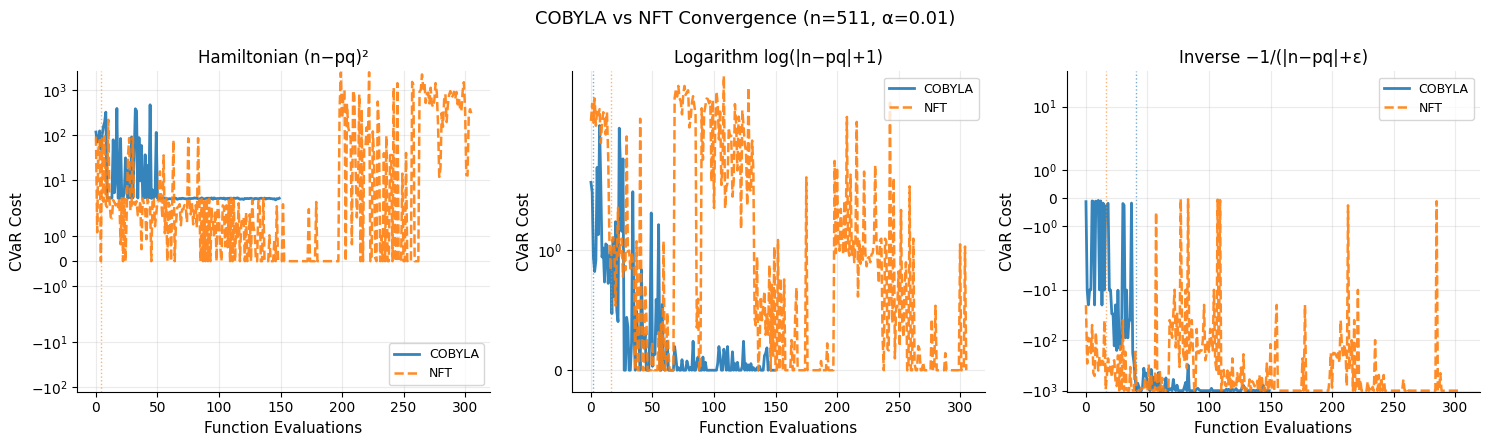

In [18]:
# COBYLA vs NFT convergence

n= 511
L= 4
shots=10000
alpha= 0.01
filename = "Optimizer_comparison.png"

Np, Nq, N   = get_qubit_counts(n)
cost_types  = ["hamiltonian", "logarithm", "inverse", "exponential"]
ct_titles   = {
    "hamiltonian": "Hamiltonian (n−pq)²",
    "logarithm"  : "Logarithm log(|n−pq|+1)",
    "inverse"    : "Inverse −1/(|n−pq|+ε)",
}
opt_styles  = {"COBYLA": ("-",  2.0, COLORS[0]),
                "NFT"   : ("--", 1.8, COLORS[1])}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, ct in zip(axes, cost_types):
    for oname, (ls, lw, color) in opt_styles.items():
        res = run_vqe(n, optimizer=oname,
                      L=L, shots=shots, alpha=alpha, cost_type=ct,
                      max_iter=150, verbose=False)
        hist = res["history"]
        ax.plot(hist, color=color, ls=ls, lw=lw, alpha=0.9, label=oname)
        if res["found"]:
            # Mark first point below 0 (inverse) or near-zero (others)
            thresh = -900 if ct == "inverse" else 1.0
            for i, v in enumerate(hist):
                if (ct == "inverse" and v < thresh) or (ct != "inverse" and v < thresh):
                    ax.axvline(i, color=color, ls=":", lw=1, alpha=0.6)
                    break
    ax.set_xlabel("Function Evaluations")
    ax.set_ylabel("CVaR Cost")
    ax.set_title(ct_titles[ct])
    ax.set_yscale("symlog")
    ax.legend()
fig.suptitle(
    f"COBYLA vs NFT Convergence (n={n}, α={alpha})", fontsize=13
)
fig.tight_layout()
fig.savefig(filename, dpi=150, bbox_inches="tight")
print(filename)

cost_landscape_contour.png
cost_landscape_slices.png


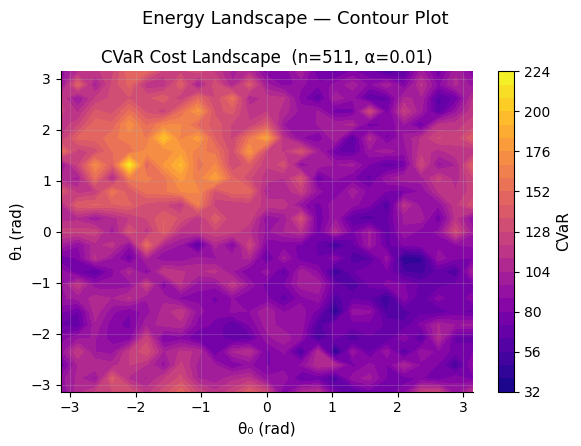

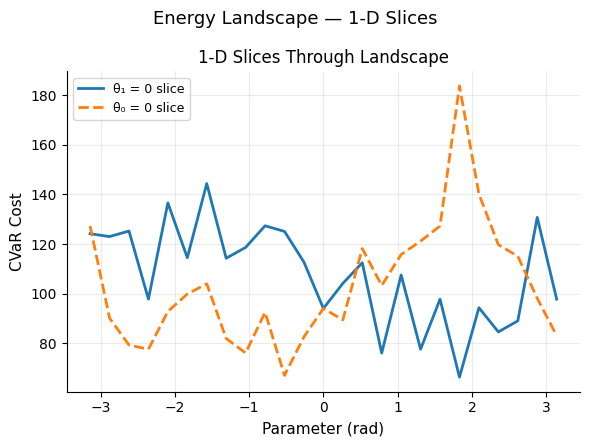

In [19]:
# Energy landscaple plots

n=511
L=4
shots=10000
alpha=0.01
grid=25

Np, Nq, N = get_qubit_counts(n)
t0 = np.linspace(-np.pi, np.pi, grid)
t1 = np.linspace(-np.pi, np.pi, grid)
Z  = np.zeros((grid, grid))
for i, a in enumerate(t0):
    for j, b in enumerate(t1):
        p = np.zeros(N * L); p[0] = a; p[min(1, N * L - 1)] = b
        cv, _ = evaluate_cost(p, n, Np, Nq, N, L, shots, alpha, "hamiltonian",SIM, {"found": False, "p": None, "q": None})
        Z[i, j] = cv

# Plot 1: CVaR Cost Landscape
fig1, ax1 = plt.subplots(figsize=(6, 4.5))
im = ax1.contourf(t0, t1, Z.T, levels=25, cmap="plasma")
ax1.set_xlabel("θ₀ (rad)"); ax1.set_ylabel("θ₁ (rad)")
ax1.set_title(f"CVaR Cost Landscape  (n={n}, α={alpha})")
fig1.colorbar(im, ax=ax1, label="CVaR")
fig1.suptitle("Energy Landscape — Contour Plot", fontsize=13)
fig1.tight_layout()
filename1 = "cost_landscape_contour.png"
fig1.savefig(filename1, dpi=150, bbox_inches="tight")
print(filename1)
#display(fig1)

# Plot 2: 1-D Slices Through Landscape
fig2, ax2 = plt.subplots(figsize=(6, 4.5))
mid = grid // 2
ax2.plot(t0, Z[:, mid], color=COLORS[0], lw=2, label="θ₁ = 0 slice")
ax2.plot(t1, Z[mid, :], color=COLORS[1], lw=2, ls="--", label="θ₀ = 0 slice")
ax2.set_xlabel("Parameter (rad)"); ax2.set_ylabel("CVaR Cost")
ax2.set_title("1-D Slices Through Landscape"); ax2.legend()
fig2.suptitle("Energy Landscape — 1-D Slices", fontsize=13)
fig2.tight_layout()
filename2 = "cost_landscape_slices.png"
fig2.savefig(filename2, dpi=150, bbox_inches="tight")
print(filename2)
#display(fig2)

cost_landscape_3d.png


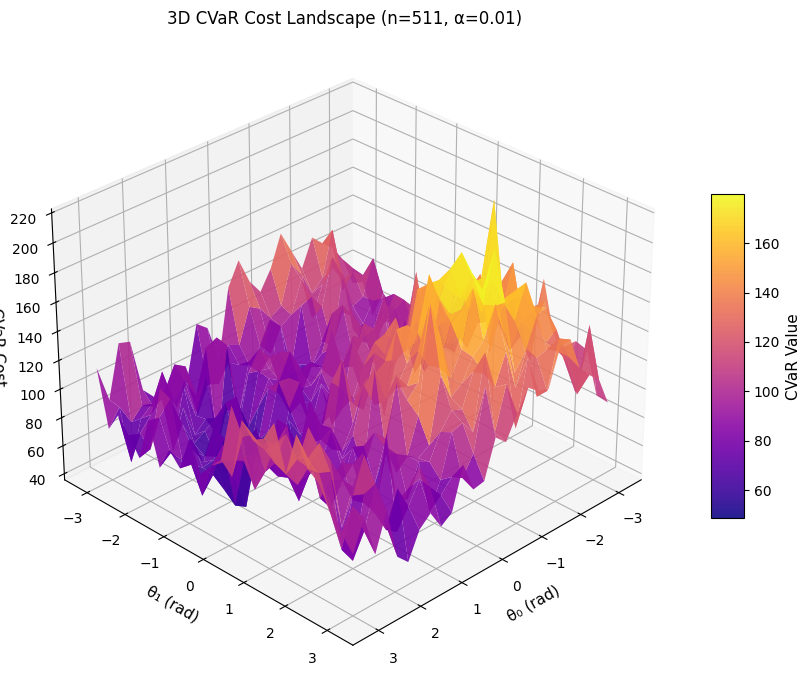

In [20]:
from mpl_toolkits.mplot3d import Axes3D

# Plot 3: 3D CVaR Cost Landscape
fig3 = plt.figure(figsize=(9, 7))
ax3 = fig3.add_subplot(111, projection='3d')

# Create a meshgrid for the 3D surface
T0, T1 = np.meshgrid(t0, t1)

# Plot the surface using your Z data
# Z.T is used to match the meshgrid orientation
surf = ax3.plot_surface(T0, T1, Z.T, cmap="plasma", edgecolor='none', antialiased=True, alpha=0.9)

ax3.set_xlabel("θ₀ (rad)")
ax3.set_ylabel("θ₁ (rad)")
ax3.set_zlabel("CVaR Cost")
ax3.set_title(f"3D CVaR Cost Landscape (n={n}, α={alpha})")

# Add a color bar for reference
fig3.colorbar(surf, ax=ax3, shrink=0.5, aspect=10, label="CVaR Value")

# Adjust view angle to see the minima clearly
ax3.view_init(elev=30, azim=45)

fig3.tight_layout()
filename3 = "cost_landscape_3d.png"
fig3.savefig(filename3, dpi=150, bbox_inches="tight")
print(filename3)

  [COBYLA, hamiltonian, shots=1000] avg_iters=69.0  (1/10 crossed threshold)
  [COBYLA, hamiltonian, shots=5000] avg_iters=33.0  (7/10 crossed threshold)
  [COBYLA, hamiltonian, shots=10000] avg_iters=21.4  (7/10 crossed threshold)
  [COBYLA, hamiltonian, shots=50000] avg_iters=42.7  (9/10 crossed threshold)
  [COBYLA, hamiltonian, shots=100000] avg_iters=48.8  (8/10 crossed threshold)
  [COBYLA, logarithm, shots=1000] avg_iters=35.2  (5/10 crossed threshold)
  [COBYLA, logarithm, shots=5000] avg_iters=28.1  (7/10 crossed threshold)
  [COBYLA, logarithm, shots=10000] avg_iters=36.8  (8/10 crossed threshold)
  [COBYLA, logarithm, shots=50000] avg_iters=33.6  (10/10 crossed threshold)
  [COBYLA, logarithm, shots=100000] avg_iters=32.3  (9/10 crossed threshold)
  [COBYLA, inverse, shots=1000] avg_iters=26.4  (5/10 crossed threshold)
  [COBYLA, inverse, shots=5000] avg_iters=24.6  (8/10 crossed threshold)
  [COBYLA, inverse, shots=10000] avg_iters=23.7  (7/10 crossed threshold)
  [COBYLA, 

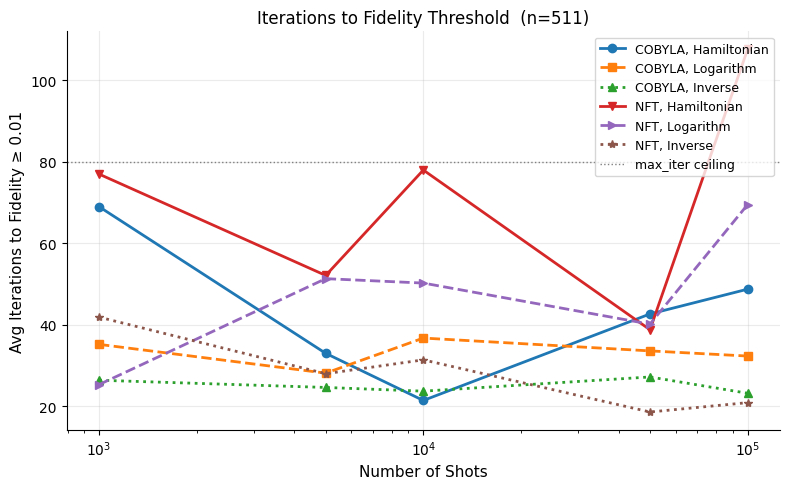

In [34]:
def run_vqe_fidelity_tracked(n, L, shots, alpha, cost_type, optimizer_name, 
                              max_iter, fidelity_threshold=0.01):
    """
    Tracks the iteration where the fidelity (fraction of shots that return
    the correct factorization) first exceeds fidelity_threshold.
    Only counts as a successful run if threshold is crossed.
    Returns (found_at_iter, max_fidelity_seen) or (None, max_fidelity_seen).
    """
    Np, Nq, N = get_qubit_counts(n)
    simulator  = AerSimulator()
    found_at   = [None]
    iter_count = [0]
    max_fid    = [0.0]
    local_best = {"found": False, "p": None, "q": None}

    params0 = np.random.uniform(-np.pi, np.pi, num_params(N, L))

    def objective(params):
        iter_count[0] += 1
        cv, best = evaluate_cost(
            params, n, Np, Nq, N, L, shots, alpha,
            cost_type, simulator, local_best,
        )

        # Rerun the same circuit to get raw counts for fidelity calculation
        # (evaluate_cost already ran it, but doesn't expose counts — so we
        #  compute fidelity from best_found as a proxy: if found this iter,
        #  fidelity >= 1/shots. We need the actual count so re-query.)
        qc = build_linear_cnot_ansatz(N, L, params)
        job = simulator.run(qc, shots=shots)
        counts = job.result().get_counts()

        # Fidelity = fraction of shots that gave correct (p, q)
        correct_shots = sum(
            count for bs, count in counts.items()
            if (lambda pv, qv: pv * qv == n and pv > 1 and qv > 1)(
                *bitstring_to_pq(bs, Np, Nq)
            )
        )
        fidelity = correct_shots / shots
        max_fid[0] = max(max_fid[0], fidelity)

        if fidelity >= fidelity_threshold and found_at[0] is None:
            found_at[0] = iter_count[0]

        return cv

    if optimizer_name == "COBYLA":
        opt = COBYLA(maxiter=max_iter)
    else:
        opt = NFT(maxiter=max_iter, maxfev=max_iter * N * L, reset_interval=32)

    opt.minimize(fun=objective, x0=params0)
    return found_at[0], max_fid[0]


# ── Fig 10 ────────────────────────────────────────────────────────────────────
n        = 511
filename = "fig10_iterations_fidelity.png"
runs     = 10
max_iter = 80
fidelity_threshold = 0.01   # 1% of shots — matches paper

configs = [
    ("COBYLA", "hamiltonian", "o", "-",  "COBYLA, Hamiltonian"),
    ("COBYLA", "logarithm",   "s", "--", "COBYLA, Logarithm"),
    ("COBYLA", "inverse",     "^", ":",  "COBYLA, Inverse"),
    ("NFT",    "hamiltonian", "v", "-",  "NFT, Hamiltonian"),
    ("NFT",    "logarithm",   ">", "--", "NFT, Logarithm"),
    ("NFT",    "inverse",     "*", ":",  "NFT, Inverse"),
]
shot_values = [1000, 5000, 10000, 50000, 100000]

fig, ax = plt.subplots(figsize=(8, 5))

for (opt, ct, mk, ls, lbl), color in zip(configs, COLORS):
    mean_iters = []
    for shots in shot_values:
        ilist = []
        for _ in range(runs):
            found_at, max_fid = run_vqe_fidelity_tracked(
                n, L=3, shots=shots, alpha=0.01,
                cost_type=ct, optimizer_name=opt,
                max_iter=max_iter,
                fidelity_threshold=fidelity_threshold,
            )
            if found_at is not None:
                ilist.append(found_at)

        mi = np.mean(ilist) if ilist else np.nan
        mean_iters.append(mi)
        print(f"  [{opt}, {ct}, shots={shots}] "
              f"avg_iters={mi:.1f}  ({len(ilist)}/{runs} crossed threshold)")

    valid = [(s, v) for s, v in zip(shot_values, mean_iters) if not np.isnan(v)]
    if valid:
        xs, ys = zip(*valid)
        ax.semilogx(xs, ys, color=color, ls=ls, marker=mk, ms=6, lw=2, label=lbl)

ax.axhline(max_iter, color="grey", ls=":", lw=1, label="max_iter ceiling")
ax.set_xlabel("Number of Shots")
ax.set_ylabel(f"Avg Iterations to Fidelity ≥ {fidelity_threshold}")
ax.set_title(f"Iterations to Fidelity Threshold  (n={n})")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(filename, dpi=150, bbox_inches="tight")
print(filename)

cost_function_convergence.png


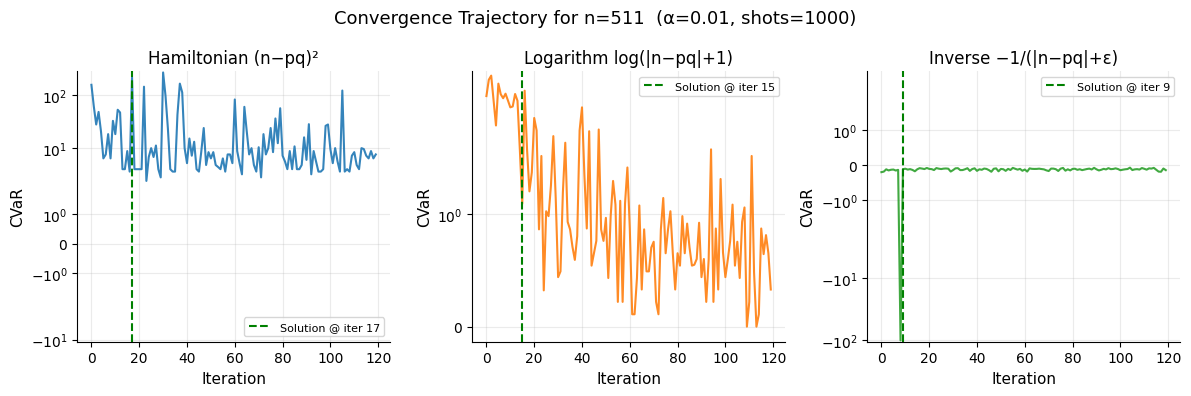

In [27]:
# Convergence trajectory for each cost function

n=511
L=4
shots=1000
alpha=0.01
filename="cost_function_convergence.png"

Np, Nq, N = get_qubit_counts(n)
ct_labels = {
    "hamiltonian": "Hamiltonian (n−pq)²",
    "logarithm":   "Logarithm log(|n−pq|+1)",
    "inverse":     "Inverse −1/(|n−pq|+ε)",
}
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (ct, color) in zip(axes, zip(ct_labels, COLORS)):
    params0 = np.random.uniform(-np.pi, np.pi, N * L)
    hist = []
    found_it = [None]
    local_best = {"found": False, "p": None, "q": None}

    def obj(p, _ct=ct,_best=local_best):
        cv, best_found = evaluate_cost(p, n, Np, Nq, N, L, shots, alpha, _ct ,SIM, _best)
        hist.append(cv)
        if best_found['p'] and found_it[0] is None: found_it[0] = len(hist)
        return cv

    minimize(obj, params0, method="COBYLA",
              options={"maxiter": 120, "rhobeg": 0.5})
    ax.plot(hist, color=color, lw=1.5, alpha=0.9)
    if found_it[0]:
        ax.axvline(found_it[0], color="green", ls="--", lw=1.5,
                    label=f"Solution @ iter {found_it[0]}")
        ax.legend(fontsize=8)
    ax.set_xlabel("Iteration"); ax.set_ylabel("CVaR")
    ax.set_title(ct_labels[ct]); ax.set_yscale("symlog")
fig.suptitle(f"Convergence Trajectory for n={n}  (α={alpha}, shots={shots})",
              fontsize=13)
fig.tight_layout()
fig.savefig(filename, dpi=150, bbox_inches="tight")
print(filename)

shot_noise.png


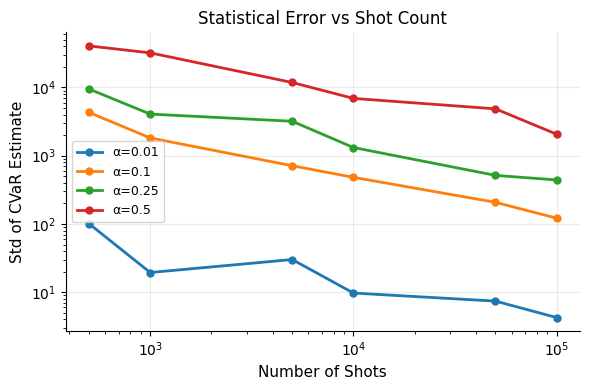

In [26]:
# shot noise sensitivity

n=511
L=4
filename="shot_noise.png"

Np, Nq, N = get_qubit_counts(n); n_params = N * L
alphas     = [0.01, 0.1, 0.25, 0.5]
shot_vals  = [500, 1000, 5000, 10000, 50000, 100000]
TRIALS     = 10

fig, ax = plt.subplots(figsize=(6, 4))

for alpha, color in zip(alphas, COLORS):
    stds = []
    for shots in shot_vals:
        params = np.random.uniform(-np.pi, np.pi, n_params); cvs = []
        for _ in range(TRIALS):
            cv,_ = evaluate_cost(p, n, Np, Nq, N, L, shots, alpha, "hamiltonian",SIM, {"found": False, "p": None, "q": None})
            cvs.append(cv)
        stds.append(np.std(cvs))
    ax.loglog(shot_vals, stds, color=color, marker="o", ms=5, lw=2,
              label=f"α={alpha}")
ax.set_xlabel("Number of Shots"); ax.set_ylabel("Std of CVaR Estimate")
ax.set_title("Statistical Error vs Shot Count")
ax.legend()

fig.tight_layout()
fig.savefig(filename, dpi=150, bbox_inches="tight")
print(filename)

## Hardware Results

In [35]:
# ── Batch hardware evaluator ──────────────────────────────────────────────────
# Submits a list of parameter vectors as ONE job (up to backend.max_circuits).
# Returns a list of CVaR costs, one per parameter vector.

def batch_evaluate_hw(
    params_list: list[np.ndarray],
    n: int,
    Np: int,
    Nq: int,
    N: int,
    L: int,
    shots: int,
    alpha: float,
    cost_type: str,
    sampler: Sampler,
    pm,
) -> list[float]:
    """
    Transpile and submit all circuits in params_list as a SINGLE IBM job.
    Returns CVaR costs in the same order as params_list.
    This collapses N queue submissions into 1.
    """
    # Build and transpile all circuits at once
    circuits_isa = [pm.run(build_linear_cnot_ansatz(N, L, p)) for p in params_list]

    # One job, many circuits
    job    = sampler.run([(qc, [], shots) for qc in circuits_isa])
    result = job.result()

    costs = []
    for i, pub_result in enumerate(result):
        counts = pub_result.data.meas.get_counts()
        eigenvalues = []
        for bs, count in counts.items():
            p_val, q_val = bitstring_to_pq(bs.replace(" ", ""), Np, Nq)
            eigenvalues.extend([cost_fn(p_val, q_val, n, cost_type)] * count)
        costs.append(cvar(eigenvalues, alpha))

    return costs

In [36]:
# ── Simulate-to-convergence, validate on hardware (1 job per trial) ───────────

def run_vqe_sim_then_hw(
    n: int,
    backend,
    L: int = 3,
    shots: int = 2000,          # use more shots on hardware to beat noise
    alpha: float = 0.5,
    cost_type: str = "hamiltonian",
    max_iter: int = 50,
    n_validation_shots: int = 8192,
    verbose: bool = True,
) -> dict:
    """
    Phase 1 — Run full COBYLA VQE on local AerSimulator (fast, free).
    Phase 2 — Submit ONE job to IBM hardware with the optimised parameters.

    Queue wait: 1 job total per trial regardless of max_iter.
    """
    Np, Nq, N = get_qubit_counts(n)
    simulator  = AerSimulator()
    best_sim   = {"found": False, "p": None, "q": None}
    history_sim = []

    if verbose:
        print(f"\n{'─'*60}")
        print(f"  Phase 1 [SIM] n={n}, N={N} qubits, L={L}, α={alpha}")
        print(f"{'─'*60}")

    # ── Phase 1: simulate to convergence ─────────────────────────────────────
    params0 = np.random.uniform(-np.pi, np.pi, num_params(N, L))

    def sim_objective(params):
        cv,_ = evaluate_cost(
            params, n, Np, Nq, N, L, shots, alpha,
            cost_type, simulator, best_sim,
        )
        history_sim.append(cv)
        return cv

    optimizer = COBYLA(maxiter=max_iter)
    result    = optimizer.minimize(fun=sim_objective, x0=params0)
    opt_params = result.x

    if verbose:
        status = f"-> {best_sim['p']}×{best_sim['q']}" if best_sim["found"] else "X not found in sim"
        print(f"  Sim done — {status} | iters={len(history_sim)}")
        print(f"\n  Phase 2 [HW ] submitting 1 job to {backend.name} …")

    # ── Phase 2: single hardware validation job ───────────────────────────────
    pm      = generate_preset_pass_manager(optimization_level=3, backend=backend)
    sampler = Sampler(backend)

    qc_isa  = pm.run(build_linear_cnot_ansatz(N, L, opt_params))
    hw_job  = sampler.run([qc_isa], shots=n_validation_shots)
    hw_counts = hw_job.result()[0].data.meas.get_counts()

    hw_found = {"found": False, "p": None, "q": None}
    hw_eigenvalues = []
    for bs, count in hw_counts.items():
        p_val, q_val = bitstring_to_pq(bs.replace(" ", ""), Np, Nq)
        hw_eigenvalues.extend([cost_fn(p_val, q_val, n, cost_type)] * count)
        if p_val * q_val == n and p_val > 1 and q_val > 1:
            hw_found.update({"found": True, "p": p_val, "q": q_val})

    hw_cvar = cvar(hw_eigenvalues, alpha)

    if verbose:
        status_hw = f"-> {hw_found['p']}×{hw_found['q']}" if hw_found["found"] else "X not found on HW"
        print(f"  HW result — {status_hw} | CVaR={hw_cvar:.4f}")
        print(f"{'─'*60}\n")

    return {
        "found_sim":    best_sim["found"],
        "found_hw":     hw_found["found"],
        "p_sim":        best_sim["p"],   "q_sim": best_sim["q"],
        "p_hw":         hw_found["p"],   "q_hw":  hw_found["q"],
        "n":            n,
        "history_sim":  history_sim,     # full convergence curve (from sim)
        "hw_cvar":      hw_cvar,
        "hw_counts":    hw_counts,
        "backend_name": backend.name,
    }


═══════════════════════════════════════════════════════  n=123  (N=8 qubits, 5 runs)
  Run 1/5 …

────────────────────────────────────────────────────────────
  Phase 1 [SIM] n=123, N=8 qubits, L=3, α=0.25
────────────────────────────────────────────────────────────
  Sim done — -> 3×41 | iters=100

  Phase 2 [HW ] submitting 1 job to ibm_fez …
  HW result — -> 3×41 | CVaR=3.9766
────────────────────────────────────────────────────────────

  Run 2/5 …

────────────────────────────────────────────────────────────
  Phase 1 [SIM] n=123, N=8 qubits, L=3, α=0.25
────────────────────────────────────────────────────────────
  Sim done — -> 3×41 | iters=100

  Phase 2 [HW ] submitting 1 job to ibm_fez …
  HW result — -> 3×41 | CVaR=0.7266
────────────────────────────────────────────────────────────

  Run 3/5 …

────────────────────────────────────────────────────────────
  Phase 1 [SIM] n=123, N=8 qubits, L=3, α=0.25
────────────────────────────────────────────────────────────
  Sim done —

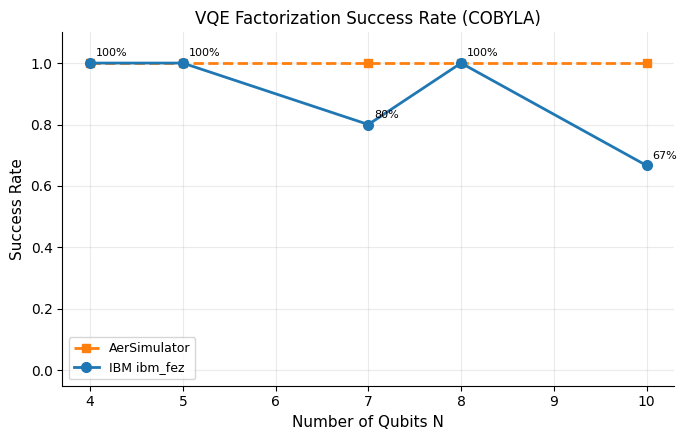

hardware_success_rate.png


In [43]:
# ── Fig 4 — Hardware success rate, minimal queue usage ───────────────────────
import json

FIG4_INSTANCES = [
    # (n,   L,  alpha,  shots, max_iter, runs)
    #(15,    3,  0.50,   1000,  50,       5),
    #(21,    3,  0.50,   1000,  50,       5),
    #(57,    3,  0.50,   2000,  80,       5)
    (123,   3,  0.25,   1000,  100,      5),
    (253,   3,  0.25,   1000,  120,      3)
]

fig4_results = {}

for (n, L, alpha, shots, max_iter, runs) in FIG4_INSTANCES:
    _, _, N = get_qubit_counts(n)
    sim_successes, hw_successes = 0, 0
    print(f"\n{'═'*55}  n={n}  (N={N} qubits, {runs} runs)")

    for run_idx in range(runs):
        print(f"  Run {run_idx+1}/{runs} …")
        res = run_vqe_sim_then_hw(
            n, hw_backend, L=L, shots=shots,
            alpha=alpha, max_iter=max_iter, verbose=True,
        )
        if res["found_sim"]: sim_successes += 1
        if res["found_hw"]:  hw_successes  += 1

    fig4_results[n] = {
        "N":               N,
        "sim_success_rate": sim_successes / runs,
        "hw_success_rate":  hw_successes  / runs,
        "runs":            runs,
    }

with open("hardware_results1.json", "w") as f:
    json.dump(fig4_results, f, indent=2)
print("\nSaved hardware_results1.json")


with open("hardware_results.json", "r") as f:
    data_main = json.load(f)

with open("hardware_results1.json", "r") as f:
    data_new = json.load(f)

combined = {**data_main, **data_new}

fig4_results1 = combined

# ── Plot ──────────────────────────────────────────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(7, 4.5))
n_vals = sorted(int(k) for k in fig4_results1.keys())
N_vals = [fig4_results1[str(n)]["N"] for n in n_vals]
sim_r  = [fig4_results1[str(n)]["sim_success_rate"] for n in n_vals]
hw_r   = [fig4_results1[str(n)]["hw_success_rate"]  for n in n_vals]

ax4.plot(N_vals, sim_r, color=COLORS[1], marker="s", ms=6, lw=2, ls="--", label="AerSimulator")
ax4.plot(N_vals, hw_r,  color=COLORS[0], marker="o", ms=7, lw=2,          label=f"IBM {hw_backend.name}")
for N_v, r in zip(N_vals, hw_r):
    ax4.annotate(f"{r:.0%}", (N_v, r), textcoords="offset points", xytext=(4, 5), fontsize=8)

ax4.set_xlabel("Number of Qubits N")
ax4.set_ylabel("Success Rate")
ax4.set_title("VQE Factorization Success Rate (COBYLA)")
ax4.set_ylim(-0.05, 1.10)
ax4.legend()
fig4.tight_layout()
fig4.savefig("hardware_success_rate.png", dpi=150, bbox_inches="tight")
plt.show()
print("hardware_success_rate.png")


Fig 5 trial 1/3 …

────────────────────────────────────────────────────────────
  Phase 1 [SIM] n=253, N=10 qubits, L=3, α=0.25
────────────────────────────────────────────────────────────
  Sim done — -> 11×23 | iters=50

  Phase 2 [HW ] submitting 1 job to ibm_fez …
  HW result — -> 23×11 | CVaR=254.3945
────────────────────────────────────────────────────────────


Fig 5 trial 2/3 …

────────────────────────────────────────────────────────────
  Phase 1 [SIM] n=253, N=10 qubits, L=3, α=0.25
────────────────────────────────────────────────────────────
  Sim done — -> 23×11 | iters=50

  Phase 2 [HW ] submitting 1 job to ibm_fez …
  HW result — -> 23×11 | CVaR=846.9824
────────────────────────────────────────────────────────────


Fig 5 trial 3/3 …

────────────────────────────────────────────────────────────
  Phase 1 [SIM] n=253, N=10 qubits, L=3, α=0.25
────────────────────────────────────────────────────────────
  Sim done — -> 23×11 | iters=50

  Phase 2 [HW ] submitting 1 job t

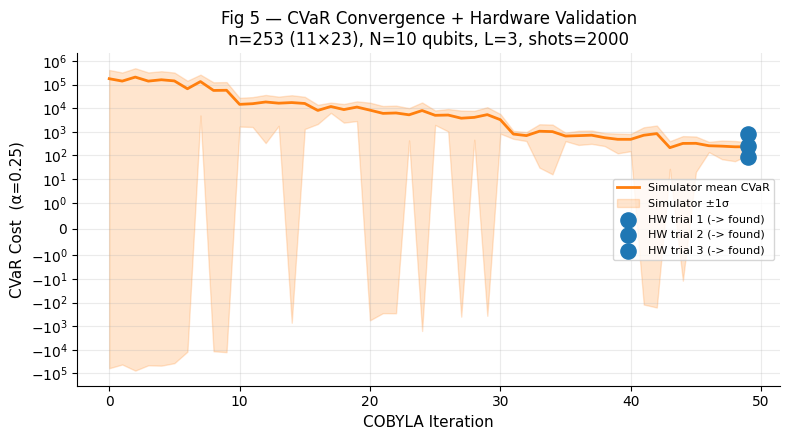

hardware_convergence.png


In [45]:
# Convergence on n=57

FIG5 = {"n": 253, "L": 3, "alpha": 0.25, "shots": 2000, "max_iter": 50}

# Run multiple trials so we can show mean ± std band (as in the paper)
N_TRIALS = 3
all_histories = []
hw_cvars, hw_found_flags = [], []

for trial in range(N_TRIALS):
    print(f"\nFig 5 trial {trial+1}/{N_TRIALS} …")
    res = run_vqe_sim_then_hw(
        FIG5["n"], hw_backend,
        L=FIG5["L"], shots=FIG5["shots"],
        alpha=FIG5["alpha"], max_iter=FIG5["max_iter"],
        n_validation_shots=8192, verbose=True,
    )
    all_histories.append(res["history_sim"])
    hw_cvars.append(res["hw_cvar"])
    hw_found_flags.append(res["found_hw"])

# Align histories to the same length (pad with last value)
max_len = max(len(h) for h in all_histories)
padded  = np.array([
    h + [h[-1]] * (max_len - len(h)) for h in all_histories
])
mean_curve = padded.mean(axis=0)
std_curve  = padded.std(axis=0)
iters      = np.arange(max_len)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig5, ax5 = plt.subplots(figsize=(8, 4.5))

# Shaded mean ± std band (simulator convergence)
ax5.plot(iters, mean_curve, color=COLORS[1], lw=2, label="Simulator mean CVaR")
ax5.fill_between(iters,
                 mean_curve - std_curve,
                 mean_curve + std_curve,
                 color=COLORS[1], alpha=0.2, label="Simulator ±1σ")

# Hardware validation CVaR points at the last iteration
for trial_idx, (hw_cv, found) in enumerate(zip(hw_cvars, hw_found_flags)):
    marker = "★" if found else "✗"
    ax5.scatter(
        max_len - 1, hw_cv,
        color=COLORS[0], s=120, zorder=5,
        label=f"HW trial {trial_idx+1} {'(-> found)' if found else '(X not found)'}",
    )

ax5.set_xlabel("COBYLA Iteration")
ax5.set_ylabel(f"CVaR Cost  (α={FIG5['alpha']})")
ax5.set_title(
    f"Fig 5 — CVaR Convergence + Hardware Validation\n"
    f"n={FIG5['n']} (11×23), N={get_qubit_counts(FIG5['n'])[2]} qubits, "
    f"L={FIG5['L']}, shots={FIG5['shots']}"
)
ax5.set_yscale("symlog", linthresh=1)
ax5.legend(fontsize=8)
fig5.tight_layout()
fig5.savefig("hardware_convergence.png", dpi=150, bbox_inches="tight")
plt.show()
print("hardware_convergence.png")

### Dry run

In [ ]:
# # ── Hardware circuit evaluator ────────────────────────────────────────────────
# from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# def evaluate_cost_hw(
#     params: np.ndarray,
#     n: int,
#     Np: int,
#     Nq: int,
#     N: int,
#     L: int,
#     shots: int,
#     alpha: float,
#     cost_type: str,
#     sampler: Sampler,          # SamplerV2 bound to real backend
#     pm,                        # preset pass manager (transpiler)
#     best_found: dict,
# ) -> float:
#     """
#     Build, transpile, and execute the VQE ansatz on real IBM hardware
#     via SamplerV2. Mirrors evaluate_cost() but targets hardware.
#     """
#     # 1. Build logical circuit (same ansatz as simulator path)
#     qc_logical = build_linear_cnot_ansatz(N, L, params)

#     # 2. Transpile to backend's native gate set & topology
#     qc_isa = pm.run(qc_logical)

#     # 3. Run on hardware via SamplerV2
#     job = sampler.run([qc_isa], shots=shots)
#     result = job.result()

#     # 4. Extract counts from PubResult (SamplerV2 API)
#     pub_result = result[0]
#     bit_array = pub_result.data.meas        # ClassicalRegister named 'meas'
#     counts = bit_array.get_counts()         # dict[str, int]

#     # 5. Compute CVaR cost (same as simulator path)
#     eigenvalues = []
#     for bitstring, count in counts.items():
#         # SamplerV2 returns bitstrings with spaces between registers — strip
#         bs_clean = bitstring.replace(" ", "")
#         p_val, q_val = bitstring_to_pq(bs_clean, Np, Nq)
#         ev = cost_fn(p_val, q_val, n, cost_type)
#         eigenvalues.extend([ev] * count)

#         if p_val * q_val == n and p_val > 1 and q_val > 1:
#             best_found["p"] = p_val
#             best_found["q"] = q_val
#             best_found["found"] = True

#     return cvar(eigenvalues, alpha), best_found

In [ ]:
# # ── Hardware VQE runner ───────────────────────────────────────────────────────
# from qiskit_algorithms.optimizers import COBYLA

# def run_vqe_hw(
#     n: int,
#     backend,                        # IBMBackend (real device)
#     L: int = 3,
#     shots: int = 1000,
#     alpha: float = 0.5,
#     cost_type: str = "hamiltonian",
#     max_iter: int = 50,
#     initial_params: np.ndarray | None = None,
#     optimization_level: int = 3,    # transpiler aggressiveness (0–3)
#     verbose: bool = True,
# ) -> dict:
#     """
#     Run one VQE trial on a real IBM backend.

#     Uses COBYLA (gradient-free) because hardware noise makes
#     gradient-based methods unstable for small qubit counts.
#     Each COBYLA iteration submits one job to the IBM queue.

#     Parameters
#     ----------
#     n                  : semiprime to factor
#     backend            : IBMBackend object (real device)
#     optimization_level : Qiskit transpiler level (3 = heaviest optimisation)

#     Returns
#     -------
#     dict with keys: found, p, q, n, iterations, history, backend_name
#     """
#     assert n % 2 == 1 and n > 1, "n must be an odd integer > 1"

#     Np, Nq, N = get_qubit_counts(n)
#     n_params   = num_params(N, L)

#     # Build pass manager once per run (expensive step)
#     pm = generate_preset_pass_manager(
#         optimization_level=optimization_level,
#         backend=backend,
#     )

#     # SamplerV2 bound to the real backend
#     sampler = Sampler(backend)

#     best_found     = {"found": False, "p": None, "q": None}
#     iteration_count = [0]
#     history        = []

#     params0 = (
#         np.random.uniform(-np.pi, np.pi, n_params)
#         if initial_params is None
#         else initial_params.copy()
#     )

#     if verbose:
#         print(f"\n{'─'*60}")
#         print(f"  [HW] Factoring n={n} on {backend.name}")
#         print(f"  Qubits N={N} | Layers L={L} | alpha={alpha} | shots={shots}")
#         print(f"{'─'*60}")

#     def objective(params):
#         iteration_count[0] += 1
#         cv, best_found = evaluate_cost_hw(
#             params, n, Np, Nq, N, L, shots, alpha,
#             cost_type, sampler, pm, best_found,
#         )
#         history.append(cv)
#         if verbose:
#             tag = (f"  -> p={best_found['p']}, q={best_found['q']}"
#                    if best_found["found"] else "")
#             print(f"  Iter {iteration_count[0]:3d} | CVaR={cv:.4f}{tag}")
#         return cv

#     optimizer = COBYLA(maxiter=max_iter)
#     result    = optimizer.minimize(fun=objective, x0=params0)

#     # Final measurement sweep with 5× shots if solution not yet found
#     if not best_found["found"]:
#         qc_final = build_linear_cnot_ansatz(N, L, result.x)
#         qc_isa   = pm.run(qc_final)
#         job      = sampler.run([qc_isa], shots=shots * 5)
#         counts   = job.result()[0].data.meas.get_counts()
#         for bs in sorted(counts, key=counts.get, reverse=True):
#             p_v, q_v = bitstring_to_pq(bs.replace(" ", ""), Np, Nq)
#             if p_v * q_v == n and p_v > 1 and q_v > 1:
#                 best_found.update({"found": True, "p": p_v, "q": q_v})
#                 break

#     if verbose:
#         if best_found["found"]:
#             print(f"\n  -> SUCCESS (HW): {n} = {best_found['p']} × {best_found['q']}")
#         else:
#             print(f"\n  X Not found after {iteration_count[0]} iterations.")
#         print(f"{'─'*60}\n")

#     return {
#         "found":        best_found["found"],
#         "p":            best_found["p"],
#         "q":            best_found["q"],
#         "n":            n,
#         "iterations":   iteration_count[0],
#         "history":      history,
#         "backend_name": backend.name,
#     }

In [ ]:
# # ── Noise-model dry run (no IBM queue credits consumed) ──────────────────────
# # Uses FakeFez which carries ibm_fez's real gate error rates and T1/T2 data.
# from qiskit_ibm_runtime.fake_provider import FakeFez
# from qiskit_aer import AerSimulator

# fake_backend  = FakeFez()
# noisy_sim     = AerSimulator.from_backend(fake_backend)

# # Monkey-patch: SamplerV2 also accepts an AerSimulator as its backend
# # so run_vqe_hw works unchanged — just pass noisy_sim instead of hw_backend.

# print("Dry-run: n=15 on FakeFez (noise model from ibm_fez calibration data)")
# dry_res = run_vqe_hw(
#     n=21, backend=noisy_sim,
#     L=3, shots=1000, alpha=0.1, max_iter=20, verbose=True,
# )
# print(f"Dry-run result: {'->' if dry_res['found'] else 'X'} "
#       f"p={dry_res['p']}, q={dry_res['q']}")

## DO NOT RUN 

In [ ]:
# # ── Fig 4 — Hardware success rate vs qubit count ──────────────────────────────
# # Mirrors the paper's Fig. 4: COBYLA on real IBM hardware.
# # WARNING: Each (n, run) submits max_iter jobs to the IBM queue.
# # Total jobs ≈ sum(runs * max_iter) across all instances.
# # Estimated wall-clock time: 30–120 min depending on queue depth.

# import json, time

# FIG4_INSTANCES = [
#     # (n,   L,  alpha,  shots, max_iter, runs)
#     (15,    3,  0.50,   1000,  50,       5),   # N=4  qubits  3×5
#     (21,    3,  0.50,   1000,  50,       5),   # N=5  qubits  3×7
#     (57,    3,  0.50,   1000,  80,       5),   # N=6  qubits  3×19
#     #(123,   3,  0.25,   1000,  100,      5),   # N=8  qubits  3×41
#     #(253,   3,  0.25,   1000,  120,      3),   # N=9  qubits  11×23  (costly)
# ]

# COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
# plt.rcParams.update({
#     "font.family": "DejaVu Sans", "axes.spines.top": False,
#     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25,
#     "axes.labelsize": 11, "axes.titlesize": 12,
# })

# fig4_hw_results = {}   # persisted for plotting & JSON export

# for (n, L, alpha, shots, max_iter, runs) in FIG4_INSTANCES:
#     _, _, N = get_qubit_counts(n)
#     successes, iters_list = 0, []
#     print(f"\n{'═'*55}")
#     print(f"  n={n}  (N={N} qubits, {runs} runs)")
#     print(f"{'═'*55}")
#     for run_idx in range(runs):
#         print(f"\n  ── Run {run_idx+1}/{runs} ──")
#         res = run_vqe_hw(
#             n, hw_backend,
#             L=L, shots=shots, alpha=alpha,
#             max_iter=max_iter, verbose=True,
#         )
#         if res["found"]:
#             successes += 1
#             iters_list.append(res["iterations"])
#     rate = successes / runs
#     avg_iters = float(np.mean(iters_list)) if iters_list else float("nan")
#     fig4_hw_results[n] = {
#         "N": N, "success_rate": rate, "avg_iters": avg_iters, "runs": runs,
#     }
#     print(f"\n  -> n={n}: success rate = {rate:.0%}, avg iters = {avg_iters:.1f}")

# # Save results so you can re-plot without re-running hardware
# with open("fig4_hw_results.json", "w") as f:
#     json.dump(fig4_hw_results, f, indent=2)
# print("\nSaved fig4_hw_results.json")

# # ── Plot Fig 4 ────────────────────────────────────────────────────────────────
# fig4, ax4 = plt.subplots(figsize=(7, 4.5))

# n_vals  = sorted(fig4_hw_results)
# N_vals  = [fig4_hw_results[n]["N"]            for n in n_vals]
# rates   = [fig4_hw_results[n]["success_rate"] for n in n_vals]

# ax4.plot(N_vals, rates, color=COLORS[0], marker="o", ms=7, lw=2,
#          label=f"IBM {hw_backend.name} (hardware)")
# for N_val, rate in zip(N_vals, rates):
#     ax4.annotate(f"{rate:.0%}", (N_val, rate),
#                  textcoords="offset points", xytext=(4, 5), fontsize=8)

# ax4.set_xlabel("Number of Qubits N")
# ax4.set_ylabel("Success Rate")
# ax4.set_title("Fig 4 — VQE Success Rate on IBM Hardware (COBYLA)")
# ax4.set_ylim(-0.05, 1.10)
# ax4.legend()
# fig4.tight_layout()
# fig4.savefig("fig4_hardware_success_rate.png", dpi=150, bbox_inches="tight")
# plt.show()
# print("fig4_hardware_success_rate.png")

In [ ]:
# # ── Fig 5 — CVaR convergence on hardware for n=253 ───────────────────────────
# # Replicates Fig. 5 of the paper: convergence trajectory of the CVaR objective
# # on real IBM hardware, shown alongside the ideal (noise-free) simulator run.

# FIG5_CONFIG = {
#     "n": 253, "L": 3, "alpha": 0.25, "shots": 1000, "max_iter": 120,
# }
# n, L, alpha, shots, max_iter = (
#     FIG5_CONFIG["n"], FIG5_CONFIG["L"], FIG5_CONFIG["alpha"],
#     FIG5_CONFIG["shots"], FIG5_CONFIG["max_iter"],
# )

# print(f"Fig 5: running n={n} on IBM hardware ({hw_backend.name}) …")
# hw_res = run_vqe_hw(
#     n, hw_backend,
#     L=L, shots=shots, alpha=alpha,
#     max_iter=max_iter, verbose=True,
# )

# print(f"\nFig 5: running n={n} on AerSimulator (noise-free reference) …")
# sim_res = run_vqe(
#     n, L=L, shots=shots, alpha=alpha,
#     cost_type="hamiltonian", max_iter=max_iter, verbose=True,
# )

# # ── Plot Fig 5 ────────────────────────────────────────────────────────────────
# fig5, ax5 = plt.subplots(figsize=(8, 4.5))

# hw_hist  = hw_res["history"]
# sim_hist = sim_res["history"]

# ax5.plot(hw_hist,  color=COLORS[0], lw=2,   alpha=0.9,
#          label=f"IBM {hw_backend.name} (hardware)")
# ax5.plot(sim_hist, color=COLORS[1], lw=2,   alpha=0.9,
#          ls="--", label="AerSimulator (noise-free)")

# # Mark first iteration where correct factors were found
# for hist, color, label_prefix in [
#     (hw_hist,  COLORS[0], "HW"),
#     (sim_hist, COLORS[1], "Sim"),
# ]:
#     found_iter = None
#     # We use a proxy: first dip below 1.0 (Hamiltonian cost near zero)
#     for i, v in enumerate(hist):
#         if v < 1.0:
#             found_iter = i
#             break
#     if found_iter is not None:
#         ax5.axvline(found_iter, color=color, ls=":", lw=1.5,
#                     label=f"{label_prefix} solution @ iter {found_iter}")

# ax5.set_xlabel("COBYLA Iteration")
# ax5.set_ylabel("CVaR Cost (α=0.25)")
# ax5.set_title(
#     f"Fig 5 — CVaR Convergence on IBM Hardware vs Simulator\n"
#     f"n={n} (11×23), N={get_qubit_counts(n)[2]} qubits, L={L}, shots={shots}"
# )
# ax5.set_yscale("symlog", linthresh=1)
# ax5.legend()
# fig5.tight_layout()
# fig5.savefig("fig5_hardware_convergence.png", dpi=150, bbox_inches="tight")
# plt.show()
# print("fig5_hardware_convergence.png")

# # Print summary
# print(f"\n  Hardware result : {'-> ' + str(hw_res['p']) + '×' + str(hw_res['q']) if hw_res['found'] else 'X not found'}")
# print(f"  Simulator result: {'-> ' + str(sim_res['p']) + '×' + str(sim_res['q']) if sim_res['found'] else 'X not found'}")